In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

import os
import sys
sys.path.insert(0, '..')

from archspace import AnticorruptionLayer, ArchSpace
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [2]:
# from os import listdir
# from os.path import isfile, join
# mypath = "./results-ACL-p-values"
# onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f))]

# list_dfs = []
# for f in onlyfiles:
#     df = pd.read_csv(mypath + "/" + f)
#     list_dfs.append(df) 
# df = pd.concat(list_dfs, axis=0, ignore_index=True)
# df.to_csv("./multi_N25_p.csv", index=False)
# df

In [3]:
# df.describe()

In [4]:
my_space = AnticorruptionLayer()
my_space.create_model('anticorruption layer')

# experiments_df, outcomes_df = my_space.load_results('./multi_N25.csv')
experiments_df, outcomes_df = my_space.load_results('./multi_N25_p.csv')

print(len(my_space.get_configurations()), "configurations")

(234, 43)
1 configurations


In [5]:
experiments_df

,scenario,N_A,N_B,r_Z_A,r_Z_B,C_SS1,r_A_SS1,r_B_SS1,p_SS1toACL_A,p_SS1toRef_A,p_SS1toACL_B,p_SS1toRef_B,r_A_ACL,r_B_ACL,r_A_SS2,r_B_SS2,model,policy
0,0,0,25,0.05,0.01,1,0.083333,1.666667,0.9,0.1,0.1,0.9,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
1,1,0,25,0.05,0.01,1,0.083333,1.666667,0.3,0.7,0.7,0.3,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
2,2,0,25,0.05,0.01,1,0.083333,1.666667,0.7,0.3,0.3,0.7,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
3,3,0,25,0.05,0.01,1,0.083333,1.666667,0.4,0.6,0.6,0.4,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
4,4,0,25,0.05,0.01,1,0.083333,1.666667,0.2,0.8,0.8,0.2,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,229,25,0,0.05,0.01,1,0.083333,1.666667,0.1,0.9,0.9,0.1,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
230,230,25,0,0.05,0.01,1,0.083333,1.666667,0.3,0.7,0.7,0.3,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
231,231,25,0,0.05,0.01,1,0.083333,1.666667,0.7,0.3,0.3,0.7,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
232,232,25,0,0.05,0.01,1,0.083333,1.666667,0.9,0.1,0.1,0.9,0.05,0.2,0.03125,0.235294,anticorruption_layer,0


In [6]:
experiments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   scenario      234 non-null    int64   
 1   N_A           234 non-null    int64   
 2   N_B           234 non-null    int64   
 3   r_Z_A         234 non-null    float64 
 4   r_Z_B         234 non-null    float64 
 5   C_SS1         234 non-null    int64   
 6   r_A_SS1       234 non-null    float64 
 7   r_B_SS1       234 non-null    float64 
 8   p_SS1toACL_A  234 non-null    float64 
 9   p_SS1toRef_A  234 non-null    float64 
 10  p_SS1toACL_B  234 non-null    float64 
 11  p_SS1toRef_B  234 non-null    float64 
 12  r_A_ACL       234 non-null    float64 
 13  r_B_ACL       234 non-null    float64 
 14  r_A_SS2       234 non-null    float64 
 15  r_B_SS2       234 non-null    float64 
 16  model         234 non-null    object  
 17  policy        234 non-null    category
dtypes: categor

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


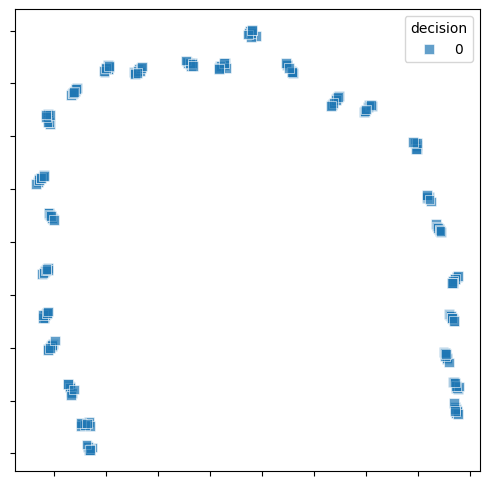

In [7]:
embeddings_df = show_configuration_space2D(experiments_df, alpha=0.7)

In [8]:
outcomes_df

,response_time,utilization
0,101.512662,0.135379
1,294.202801,0.988126
2,107.532000,0.496755
3,193.744509,0.969914
4,503.921065,0.994053
...,...,...
229,333.064584,0.168529
230,428.920038,0.496772
231,1838.705541,0.627512
232,7268.132255,0.623962


In [9]:
outcomes_df.describe()

,response_time,utilization
count,234.000000,234.000000
mean,392.968851,0.749006
std,552.946781,0.153155
min,101.512662,0.135379
25%,211.192748,0.651076
50%,297.311635,0.731353
75%,380.418763,0.873826
max,7268.132255,0.999385


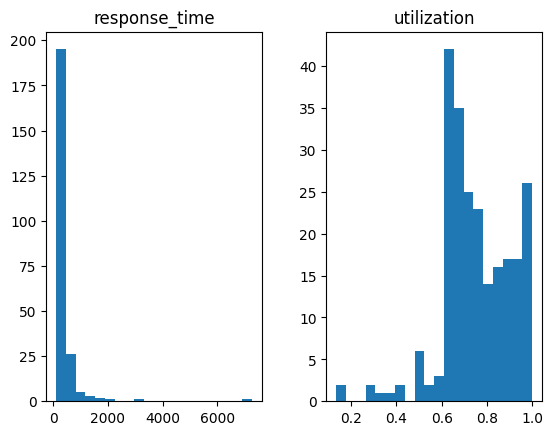

In [10]:
outcomes_df.hist(bins=20, grid=False)
plt.show()

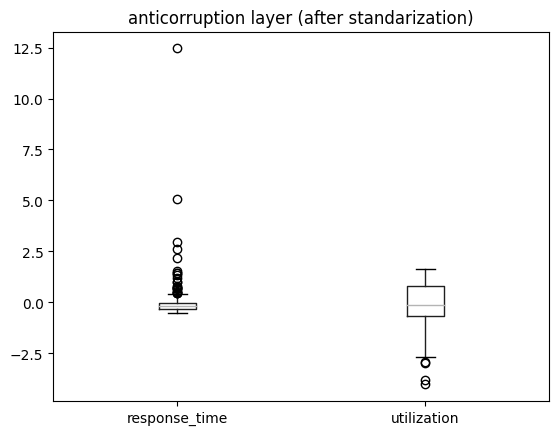

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('anticorruption layer (after standarization)')
plt.show()

# TODO: I should probably remove outliers for response time

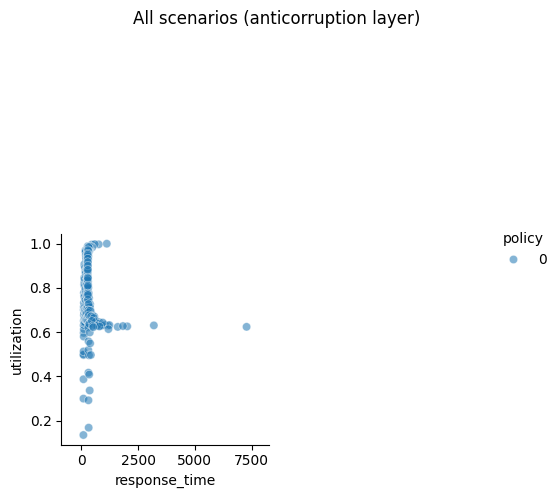

In [12]:
# show_pairplot(experiments_df, outcomes, title='All scenarios (anticorruption layer)', kind='sns')
show_pairplot(my_space, title='All scenarios (anticorruption layer)', kind='sns', group='policy', legend=True) #, filename=None)

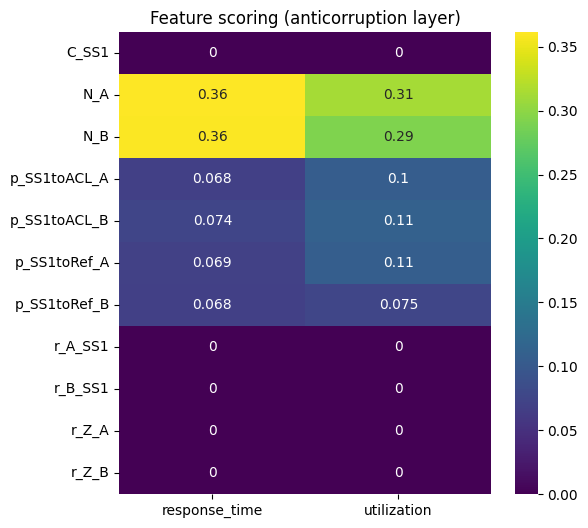

,response_time,utilization
0,,
C_SS1,0.000000,0.000000
N_A,0.361374,0.312857
N_B,0.358724,0.290917
p_SS1toACL_A,0.068129,0.104746
p_SS1toACL_B,0.074138,0.110246
p_SS1toRef_A,0.069254,0.106123
p_SS1toRef_B,0.068381,0.075112
r_A_SS1,0.000000,0.000000
r_B_SS1,0.000000,0.000000


In [13]:
policy_size = (5,3)
# fs = show_feature_scores(my_space, title='Feature scoring (anticorruption layer)', size=policy_size) #, filename=None)  
filter_params = ['N_A', 'N_B', 'r_Z_A', 'r_Z_B', 'C_SS1', 'r_A_SS1','r_B_SS1', 'p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toACL_B', 'p_SS1toRef_B']
fs = show_feature_scores(my_space, title='Feature scoring (anticorruption layer)', parameters=filter_params) #, filename=None)  
fs

Absolute ranges: [(101, 7269), (0.13, 1.0)]
response_time [100.9, 2490.3, 4879.7, 7269.1]
utilization [0.03, 0.3866666666666667, 0.7433333333333334, 1.1]


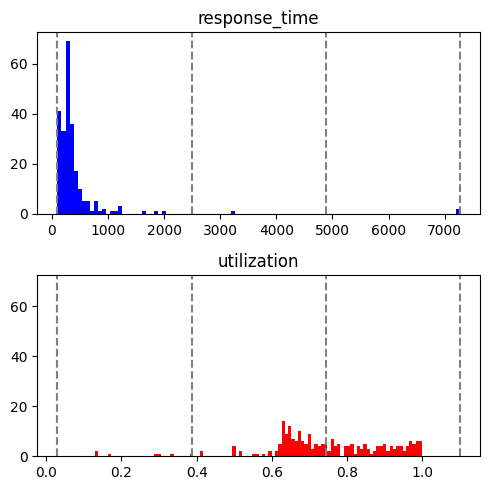

{'response_time': [100.9, 2490.3, 4879.7, 7269.1],
 'utilization': [0.03, 0.3866666666666667, 0.7433333333333334, 1.1]}

In [14]:
MIN_RESPONSE_TIME, MAX_RESPONSE_TIME = (101, 7269) #(285.0, 501.0)
MIN_UTILIZATION, MAX_UTILIZATION = (0.13, 1.0) # (0.33, 1.0)
MIN_MAX_RANGES = [(MIN_RESPONSE_TIME, MAX_RESPONSE_TIME), (MIN_UTILIZATION, MAX_UTILIZATION)]
print('Absolute ranges:', MIN_MAX_RANGES)

show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

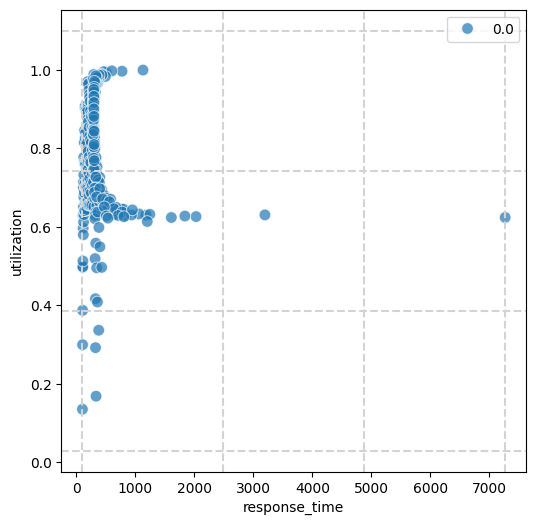

In [15]:
df = outcomes_df.copy()
df['decision'] = experiments_df['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7)

In [16]:
print("Configurations:", my_space.get_configurations())

Configurations: [0]


In [17]:
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)

config = 0
exp_df, out_df, discrete_out_df = my_space.get_experiment(config)

# print(exp_df.head())
# print(out_df.head())
# print(discrete_exp_df)
print(my_space.available_tradeoffs_)
print("Tradeoffs for ", config,"-->", AnticorruptionLayer.get_tradeoffs(discrete_out_df))
discrete_out_df.head(10)

Experiments: (234, 18)
Counter({'fast,average': 114, 'fast,high': 113, 'fast,low': 5, 'average,average': 1, 'slow,average': 1})
Tradeoffs for  0 --> Counter({'fast,average': 114, 'fast,high': 113, 'fast,low': 5, 'average,average': 1, 'slow,average': 1})


,response_time,utilization
0,fast,low
1,fast,high
2,fast,average
3,fast,high
4,fast,high
5,fast,high
6,fast,average
7,fast,high
8,fast,low
9,fast,average


In [2]:
my_space.available_tradeoffs_

NameError: name 'my_space' is not defined

In [1]:
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.2, remove_outliers=3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

NameError: name 'my_space' is not defined

In [20]:
X_train[['response_time', 'utilization']].describe()

,response_time,utilization
count,184.000000,184.000000
mean,333.159244,0.755906
std,240.380818,0.139857
min,104.205254,0.299704
25%,209.149583,0.657318
50%,295.503360,0.737290
75%,360.262351,0.876199
max,2028.120047,0.997349


In [21]:
X_test[['response_time', 'utilization']].describe()

,response_time,utilization
count,46.000000,46.000000
mean,429.457742,0.752663
std,324.368027,0.158698
min,113.126642,0.292183
25%,232.055315,0.635442
50%,315.588289,0.703702
75%,485.234416,0.878331
max,1608.886541,0.999385


In [22]:
my_space.import_dataset(X_train, y_train)

In [23]:
# reference_tradeoff = None #'slow,average'
# reference_tradeoff = ['fast,high', 'slow,high']
# r1, qat = my_space.compute_robustness([config], reference_tradeoff)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# print()

# list_of_configs = my_space.get_nearest_configurations(config, k=1)
# # list_of_configs = configs_df.values.tolist()
# # print(all(isinstance(elem, list) for elem in list_of_configs), list_of_configs)
# r1, qat = my_space.compute_robustness(list_of_configs, reference_tradeoff) 
# print("Robustness of list of solutions", list_of_configs, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# # print(configs_df)
# print()
# qa_config = 'fast,high'
# qa_configs = my_space.get_nearest_tradeoffs(qa_config, k=1)
# print("Neighbors of:", qa_configs)
# print()
# qat = my_space.get_nearest_tradeoffs(qa_config, k=2)
# r1, qat = my_space.compute_robustness([config], qa_config)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# r1, qat = my_space.compute_robustness([config], qa_configs[0:2])
# print("Robustness of single solution", config, "w.r.t list of tradeoffs:", qat, "-->", round(r1*100, 2), "%")
# print()

Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 27.79it/s]


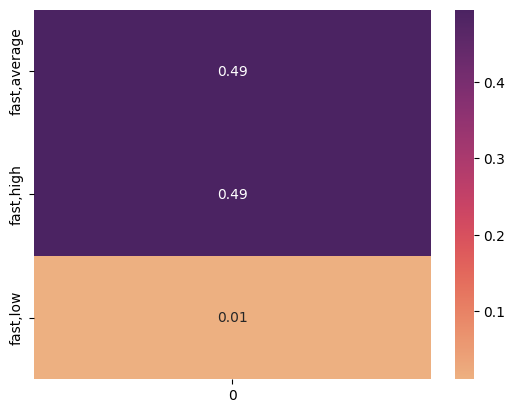

,0
"fast,average",0.494565
"fast,high",0.494565
"fast,low",0.010870


In [24]:
print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./anticorruption_layer_robustness_matrix.csv')

sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
plt.show()
df

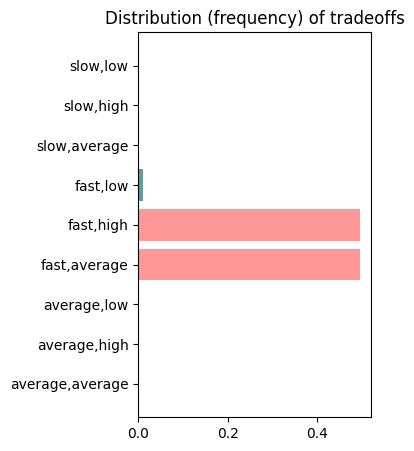

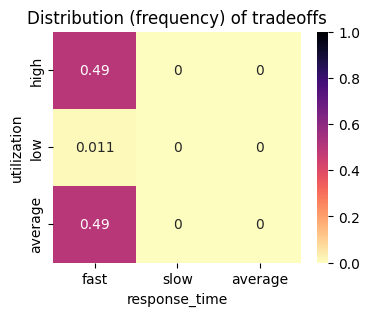

In [25]:
show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

In [26]:
cluster_labels = my_space._get_cluster_labels(encode=True)
print(my_space.available_tradeoffs_.keys())
set(cluster_labels)

dict_keys(['fast,high', 'fast,average', 'fast,low'])


{0, 1, 2}

In [27]:
kp = ['N_A', 'N_B'] + ['p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toACL_B', 'p_SS1toRef_B']
rules, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())

for r in rules:
    print(r)

# cart_model.stats_to_dataframe()
# cart_model.boxes_to_dataframe()

(184, 6) Index(['N_A', 'N_B', 'p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toACL_B',
       'p_SS1toRef_B'],
      dtype='object')
Running CART ...
nodes: 15 leaves: 13
if N_B > 6.5 and p_SS1toRef_A > 0.35 then class: fast,high (proba: 92.0%) | based on 91 samples
if N_B > 6.5 and p_SS1toRef_A <= 0.35 then class: fast,average (proba: 85.0%) | based on 48 samples
if N_B <= 6.5 then class: fast,average (proba: 96.0%) | based on 45 samples


In [29]:
# print(help(sklearn.tree._tree.Tree))
# fig = cart_model.show_tree()
# fig.set_size_inches((18, 12))
# plt.show()

|--- feature_1 <= 6.50
|   |--- class: 1
|--- feature_1 >  6.50
|   |--- feature_3 <= 0.35
|   |   |--- class: 1
|   |--- feature_3 >  0.35
|   |   |--- class: 0



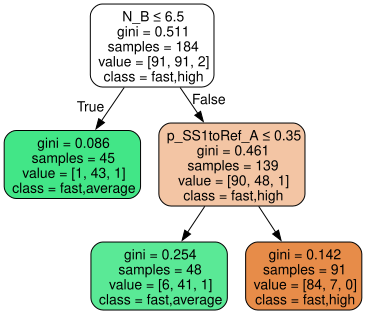

In [37]:
class_names =  my_space._get_cluster_labels()
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(cart_model.clf))
# pprint(tree.export_text(prunedTree))

graph

In [32]:
# y = my_space._get_cluster_labels(my_space.discrete_outcomes_df_, encode=True)
# x = my_space.experiments_df_.drop(columns=['policy', 'model', 'scenario'])
# viz_model = dtreeviz.model(cart_model.clf, X_train=x, y_train=y)
# viz_model

In [36]:
# my_space.import_dataset(X_test, y_test)
my_space.import_dataset(X_train, y_train)
print("  Computing robustness for all configurations...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
df

  Computing robustness for all configurations...
Counter({'fast,high': 91, 'fast,average': 91, 'fast,low': 2})


100%|██████████| 1/1 [00:00<00:00, 56.18it/s]


,0
"fast,average",0.494565
"fast,high",0.494565
"fast,low",0.010870


In [37]:
warnings.filterwarnings('ignore')
my_space.import_dataset(X_train, y_train)

kp = ['N_A', 'N_B'] + ['p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toACL_B', 'p_SS1toRef_B']

for qa_label in my_space.available_tradeoffs_.keys():
    my_space.import_dataset(X_train, y_train)
    n = my_space.available_tradeoffs_[qa_label]
    
    if n > 0:
        print("Checking (with PRIM) ----")
        property_to_check = my_space.get_property_box(qa_label)
        print("  ", qa_label, property_to_check)
        
        box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, verbose=False)
        print("  New ranges:",  prange)

        my_space.import_dataset(X_test, y_test)
        my_space.adjust_parameters(prange)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)

        print("  Computing robustness for all configurations...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()

Checking (with PRIM) ----
   fast,high {'response_time': (100.9, 2490.3), 'utilization': (0.7433333333333334, 1.1)}
  New ranges: {'N_A': {'min': 0.0, 'max': 15.0}, 'p_SS1toACL_A': {'min': 0.1, 'max': 0.55}}
  Experiments: (16, 18)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 411.00it/s]


             0
fast,high  1.0
Checking (with PRIM) ----
   fast,average {'response_time': (100.9, 2490.3), 'utilization': (0.3866666666666667, 0.7433333333333334)}
  New ranges: {'N_A': {'min': 1.0, 'max': 25.0}, 'p_SS1toACL_A': {'min': 0.75, 'max': 0.9}}
  Experiments: (11, 18)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 382.41it/s]

                0
fast,average  1.0
Checking (with PRIM) ----
   fast,low {'response_time': (100.9, 2490.3), 'utilization': (0.03, 0.3866666666666667)}
  New ranges: {'p_SS1toACL_A': {'min': 0.15000000000000002, 'max': 0.8500000000000001}}
  Experiments: (33, 18)
  Computing robustness for all configurations...



100%|██████████| 1/1 [00:00<00:00, 152.04it/s]


                     0
fast,average  0.515152
fast,high     0.484848


In [38]:
my_space.import_dataset(X_train, y_train)

# AnticorruptionLayer.get_property_box('fast,high', label_values_df)
qa_label = 'fast,average' # 'fast,average' # 'fast,high'
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

fast,average {'response_time': (100.9, 2490.3), 'utilization': (0.3866666666666667, 0.7433333333333334)}


In [ ]:
# my_space.experiments_df_.columns

In [39]:
# kp = ['N_A', 'N_B'] + ['p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toACL_B', 'p_SS1toRef_B']
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp)
# box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp)
prange

Instances satisfying property: False    93
True     91
Name: count, dtype: int64
Total instances: (184, 6)
Running PRIM ... emaw
1 boxes


{'p_SS1toACL_A': {'min': 0.75, 'max': 0.9}, 'N_A': {'min': 1.0, 'max': 25.0}}

In [40]:
prim_model.boxes_to_dataframe()

box 1      
               min   max
p_SS1toACL_A  0.75   0.9
N_A           1.00  25.0

In [41]:
prim_model.stats_to_dataframe()

,coverage,density,mass,res_dim
box 1,0.406593,1.0,0.201087,2


[<Figure size 640x480 with 1 Axes>]

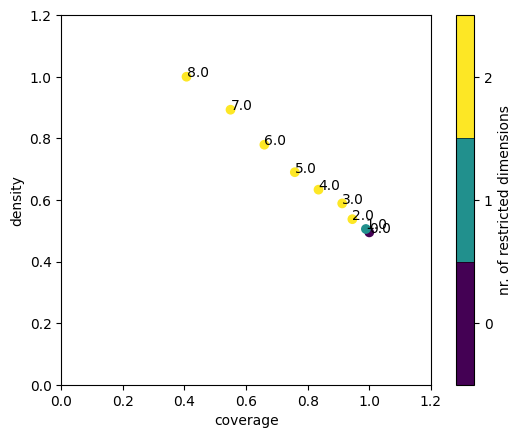

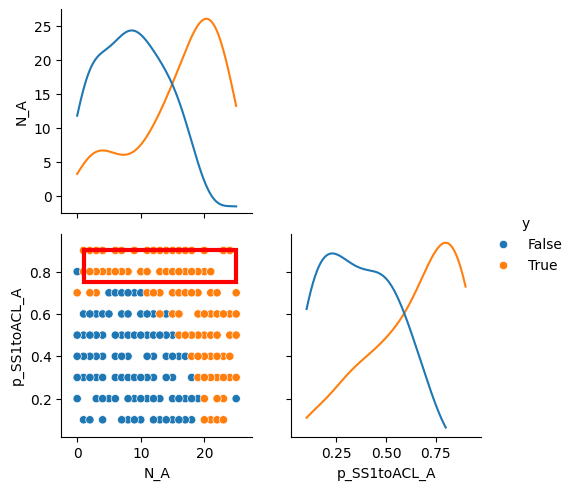

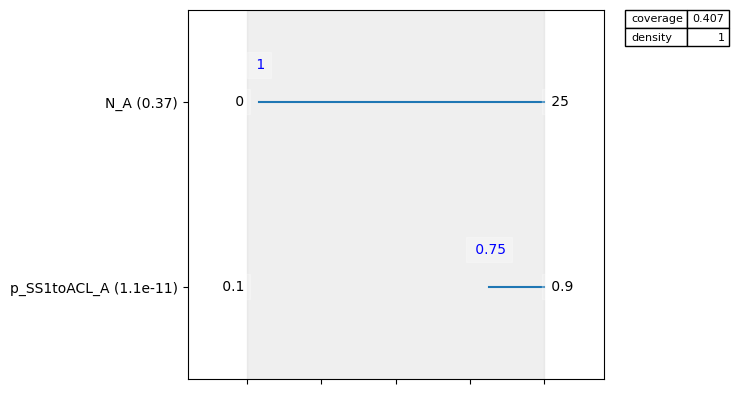

In [42]:
# EMAWorkbench
# fig = plt.figure(figsize=(24,12))
box1.show_tradeoff(annotated=True)
box1.show_pairs_scatter(upper='none', lower='scatter')
box1.inspect(style='graph')

In [ ]:
# Rhodium
# fig = plt.figure(figsize=(24,12))
# box1.show_tradeoff()
# box1.show_details()
# plt.show()

In [ ]:
# For Rhodium only
# boxes = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, n_boxes=True)
# for b in boxes:
#     # print(ArchSpace.get_limits(b).shape)
#     box_shape = ArchSpace.get_box_limits(b).shape[0]
#     if box_shape > 0:
#         b.show_tradeoff()
#         b.show_details()
#         plt.show()

In [43]:
my_space.import_dataset(X_test, y_test)

In [44]:
my_space.experiments_df_

,scenario,N_A,N_B,r_Z_A,r_Z_B,C_SS1,r_A_SS1,r_B_SS1,p_SS1toACL_A,p_SS1toRef_A,p_SS1toACL_B,p_SS1toRef_B,r_A_ACL,r_B_ACL,r_A_SS2,r_B_SS2,model,policy
0,202,22,3,0.05,0.01,1,0.083333,1.666667,0.8,0.2,0.2,0.8,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
1,148,16,9,0.05,0.01,1,0.083333,1.666667,0.3,0.7,0.7,0.3,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
2,58,6,19,0.05,0.01,1,0.083333,1.666667,0.1,0.9,0.9,0.1,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
3,215,23,2,0.05,0.01,1,0.083333,1.666667,0.7,0.3,0.3,0.7,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
4,186,20,5,0.05,0.01,1,0.083333,1.666667,0.7,0.3,0.3,0.7,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
5,221,24,1,0.05,0.01,1,0.083333,1.666667,0.2,0.8,0.8,0.2,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
6,98,10,15,0.05,0.01,1,0.083333,1.666667,0.4,0.6,0.6,0.4,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
7,86,9,16,0.05,0.01,1,0.083333,1.666667,0.4,0.6,0.6,0.4,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
8,9,1,24,0.05,0.01,1,0.083333,1.666667,0.7,0.3,0.3,0.7,0.05,0.2,0.03125,0.235294,anticorruption_layer,0
9,173,19,6,0.05,0.01,1,0.083333,1.666667,0.1,0.9,0.9,0.1,0.05,0.2,0.03125,0.235294,anticorruption_layer,0


In [49]:
prange

{'p_SS1toACL_A': {'min': 0.75, 'max': 0.9}, 'N_A': {'min': 1.0, 'max': 25.0}}

Reducing range for tradeoff: fast,average {'response_time': (100.9, 2490.3), 'utilization': (0.3866666666666667, 0.7433333333333334)}
New ranges: {'p_SS1toACL_A': {'min': 0.75, 'max': 0.9}, 'N_A': {'min': 1.0, 'max': 25.0}}
Experiments: (11, 18)


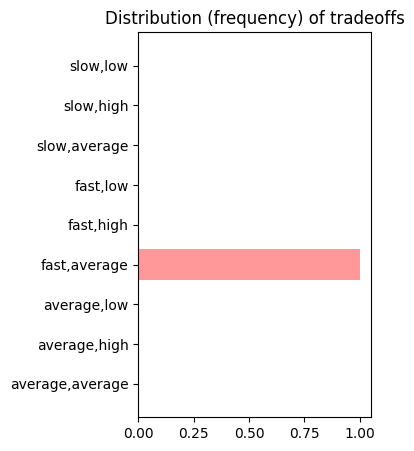

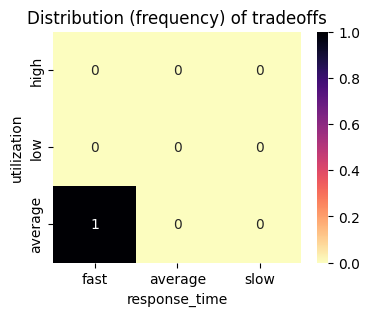

In [45]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

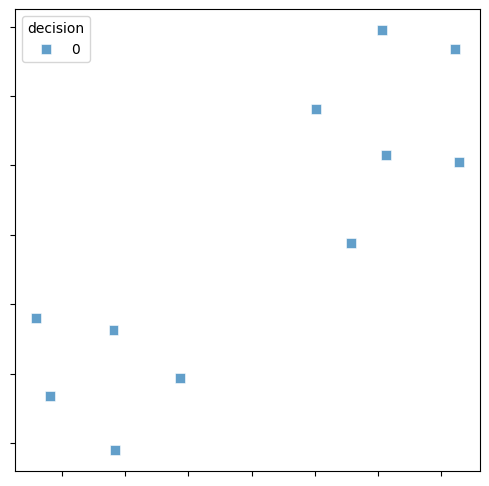

In [46]:
embeddings_df = show_configuration_space2D(my_space.experiments_df_, alpha=0.7)

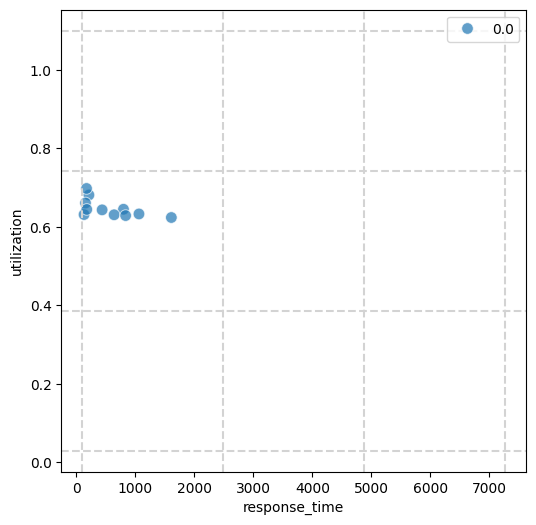

In [47]:
df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7)

In [48]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 187.16it/s]

0


,0
"fast,average",1.0
